In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [15]:
catalog.list()

['scoring_data_raw', 'encoded_data', 'final_data', 'parameters']

In [16]:
final_data = catalog.load("final_data")

[04/07/25 14:11:57] INFO     Loading data from final_data (CSVDataset)...                       ]8;id=447416;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=980533;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py#401\401]8;;\

In [17]:
final_data.shape

(5686, 26)

In [18]:
final_data.head(5)

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,0.000000,0.059869,0.036590,0.256098,0.0,0.000000,0.145236,0.1,0.163636,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1,0.002252,0.171050,0.071234,0.170732,0.0,0.333333,0.187509,0.0,0.254545,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,0.004505,0.028773,0.010261,0.097561,0.0,0.000000,0.230038,0.1,0.181818,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,0.006757,0.240856,0.122655,0.073171,0.0,0.000000,0.143646,0.0,0.254545,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.006757,0.071663,0.038117,0.219512,0.0,0.000000,0.156162,0.1,0.145455,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
raw_data = catalog.load("scoring_data_raw")

                    INFO     Loading data from scoring_data_raw (CSVDataset)...                 ]8;id=308843;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=43106;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py#401\401]8;;\

In [20]:
raw_data.shape

(5960, 13)

In [21]:
raw_data.head(5)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [22]:
df = final_data.copy()

In [23]:
# Identify objective variable (last column assumed)
objective_var = 'BAD'

# Separate features and target
X = df.drop(columns=[objective_var])
y = df[objective_var]

In [24]:
# Select only numeric features
X_numeric = X.select_dtypes(include=[np.number])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

In [25]:
# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [26]:
# Explained variance
explained_var = pca.explained_variance_ratio_
print("Explained variance per component:", explained_var)

Explained variance per component: [1.03829620e-01 8.72953633e-02 8.06328589e-02 6.77641428e-02
 5.60471374e-02 5.30532925e-02 5.22244562e-02 4.90145067e-02
 4.56036797e-02 4.21512083e-02 4.15868542e-02 3.69597189e-02
 3.64804456e-02 3.51678157e-02 3.34804560e-02 3.17556864e-02
 3.00473619e-02 2.85247268e-02 2.65881669e-02 2.29812492e-02
 1.96197532e-02 1.16811094e-02 7.51038984e-03 3.63004814e-17
 0.00000000e+00]


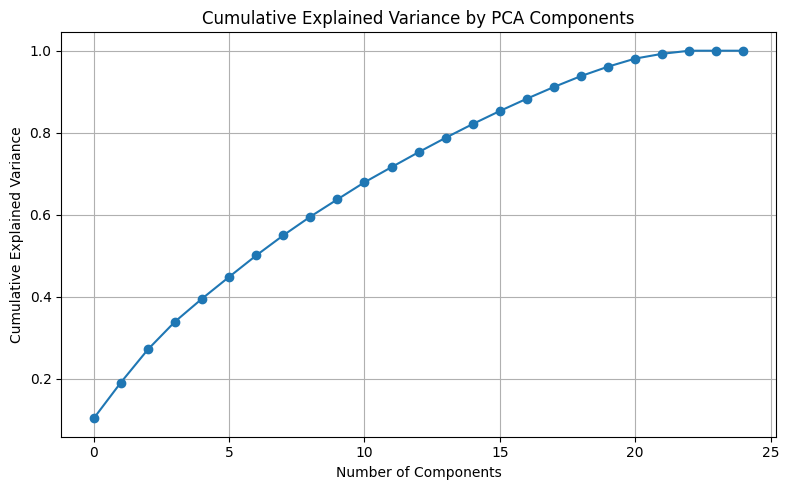

In [27]:
# Scree plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X_numeric.columns))],
                        index=X_numeric.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC1'].sort_values(ascending=False)
print("\nCorrelation of variables with PC1:")
print(correlations)


Correlation of variables with PC1:
MORTDUE                0.503923
VALUE                  0.502412
CLNO                   0.341517
JOB_ProfExe            0.277552
LOAN                   0.258223
CLAGE                  0.190853
REASON_DebtCon         0.161916
DEBTINC                0.129203
JOB_Mgr                0.097170
JOB_Self               0.092744
DEROG_missing          0.068775
NINQ                   0.036292
JOB_Sales              0.036117
DELINQ                 0.018520
DELINQ_missing         0.010729
YOJ                    0.002220
NINQ_missing           0.000401
VALUE_missing         -0.019539
JOB_Office            -0.030221
REASON_Not Provided   -0.046979
DEROG                 -0.049785
DEBTINC_missing       -0.073291
JOB_Not Provided      -0.074115
REASON_HomeImp        -0.148773
JOB_Other             -0.298536
Name: PC1, dtype: float64


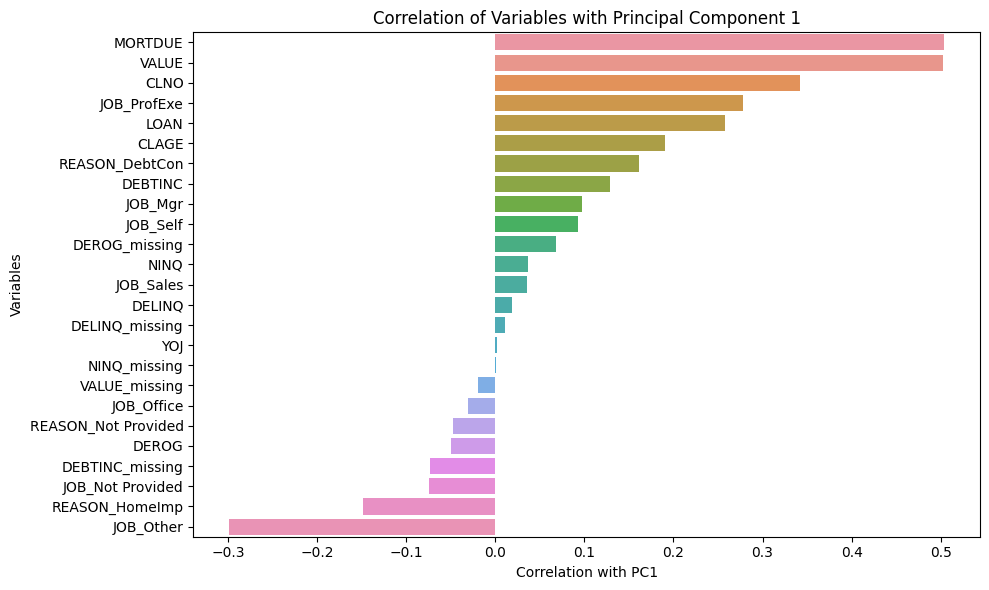

In [29]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Correlation of Variables with Principal Component 1')
plt.xlabel('Correlation with PC1')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X_numeric.columns.tolist() + [objective_var]]
corr_matrix = full_data.corr()


Correlation of each variable with objective variable:
DEBTINC_missing        0.543522
DELINQ                 0.363374
DEROG                  0.283940
VALUE_missing          0.254645
NINQ                   0.179223
DEBTINC                0.146302
JOB_Other              0.063146
JOB_Sales              0.052512
JOB_Self               0.040417
JOB_Mgr                0.033520
REASON_HomeImp         0.027886
REASON_Not Provided    0.025611
CLNO                  -0.010400
REASON_DebtCon        -0.036395
JOB_Not Provided      -0.039474
VALUE                 -0.042000
JOB_ProfExe           -0.047665
MORTDUE               -0.048014
NINQ_missing          -0.058835
YOJ                   -0.063236
LOAN                  -0.074167
JOB_Office            -0.082825
DELINQ_missing        -0.088281
DEROG_missing         -0.094059
CLAGE                 -0.181598
Name: BAD, dtype: float64


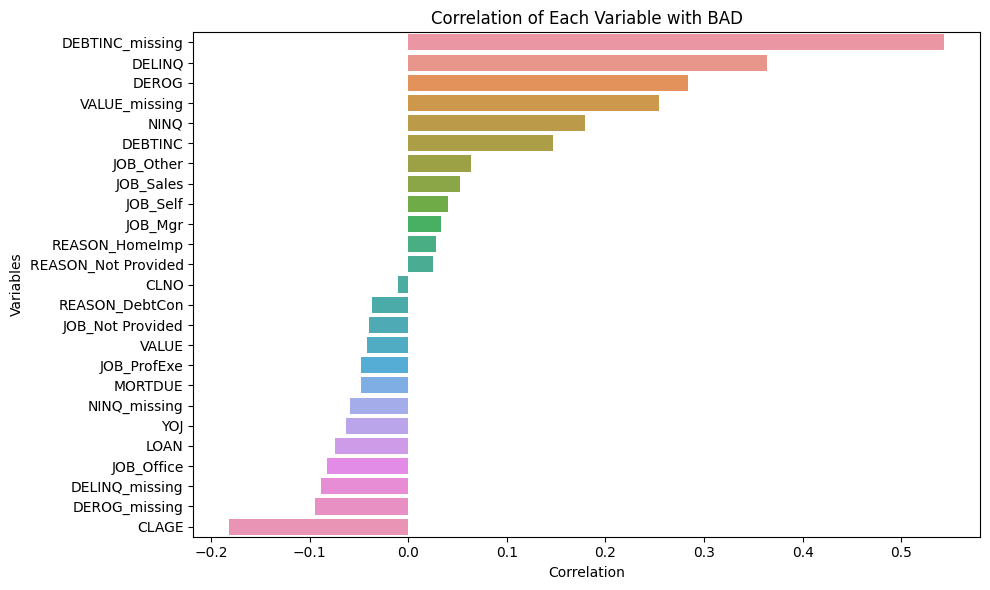

In [31]:
# Correlation with objective variable
obj_corr = corr_matrix[objective_var].drop(objective_var).sort_values(ascending=False)
print("\nCorrelation of each variable with objective variable:")
print(obj_corr)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=obj_corr.values, y=obj_corr.index)
plt.title(f'Correlation of Each Variable with {objective_var}')
plt.xlabel('Correlation')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

In [35]:
# Biplot
def biplot(score, coeff, labels=None, clusters=None):
    xs = score[:, 0]
    ys = score[:, 1]
    plt.figure(figsize=(10, 8))
    
    if clusters is not None:
        sns.scatterplot(x=xs, y=ys, hue=clusters, palette='Set2', s=70, alpha=0.8)
    else:
        plt.scatter(xs, ys, c='gray', s=50, alpha=0.6)
    
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0]*2, coeff[i, 1]*2, color='r', alpha=0.6, head_width=0.05)
        if labels is None:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, f"Var{i+1}", color='black', ha='center', va='center')
        else:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, labels[i], color='black', ha='center', va='center')
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title('PCA Biplot')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

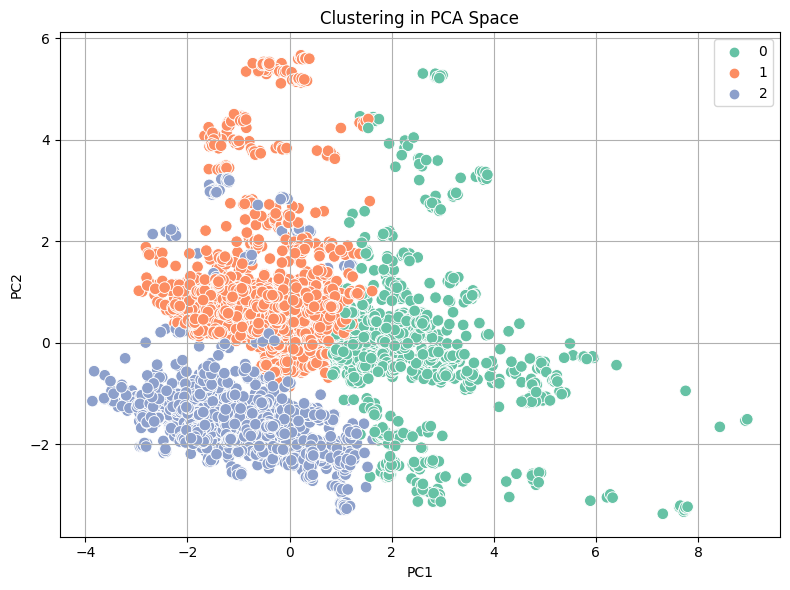

In [36]:
# Add clustering using KMeans (choose 3 clusters arbitrarily — you can use elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Plot PCA scatter with clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2', s=70)
plt.title('Clustering in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()

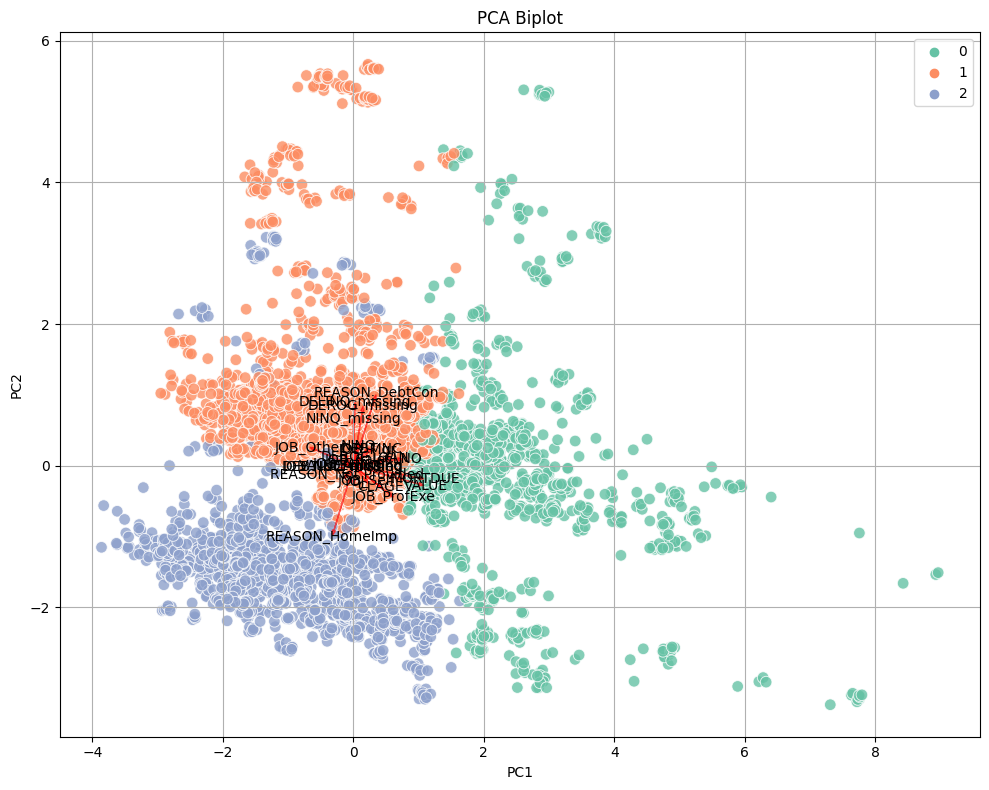

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:5                                                                                    │
│                                                                                                  │
│    2 biplot(X_pca, pca.components_.T, labels=X_numeric.columns, clusters=clusters)               │
│    3                                                                                             │
│    4 # Correlation of variables with PC1 and PC2                                                 │
│ ❱  5 loadings = pd.DataFrame(pca.components_.T,                                                  │
│    6 │   │   │   │   │   │   columns=['PC1', 'PC2'],                                             │
│    7 │   │   │   │   │   │   index=X_numeric.columns)                                            │
│    8 print("\nPCA Loadings (correlation of variables with PCs):")                                │
│                                                                                                  │
│ /Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/pandas/core/frame.py:827 in      │
│ __init__                                                                                         │
│                                                                                                  │
│     824 │   │   │   │   │   copy=_copy,                                                          │
│     825 │   │   │   │   )                                                                        │
│     826 │   │   │   else:                                                                        │
│ ❱   827 │   │   │   │   mgr = ndarray_to_mgr(                                                    │
│     828 │   │   │   │   │   data,                                                                │
│     829 │   │   │   │   │   index,                                                               │
│     830 │   │   │   │   │   columns,                                                             │
│                                                                                                  │
│ /Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/pandas/core/internals/constructi │
│ on.py:336 in ndarray_to_mgr                                                                      │
│                                                                                                  │
│    333 │   │   values.shape[0], values.shape[1], index=index, columns=columns                    │
│    334 │   )                                                                                     │
│    335 │                                                                                         │
│ ❱  336 │   _check_values_indices_shape_match(values, index, columns)                             │
│    337 │                                                                                         │
│    338 │   if typ == "array":                                                                    │
│    339 │   │   if issubclass(values.dtype.type, str):                                            │
│                                                                                                  │
│ /Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/pandas/core/internals/constructi │
│ on.py:420 in _check_values_indices_shape_match                                                   │
│                                                                                                  │
│    417 │   │                                                                                     │
│    418 │   │   passed = values.shape                                                             │
│    419 │   │   implied = (len(index), len(columns))                                              │
│ ❱  420 │   │   raise ValueError(f"Shape of passed values is

In [37]:
# Show biplot with clusters
biplot(X_pca, pca.components_.T, labels=X_numeric.columns, clusters=clusters)

# Correlation of variables with PC1 and PC2
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=X_numeric.columns)
print("\nPCA Loadings (correlation of variables with PCs):")
print(loadings)

# Correlation with objective variable
corr_matrix = df[X_numeric.columns.tolist() + [objective_var]].corr()
obj_corr = corr_matrix[objective_var].drop(objective_var).sort_values(ascending=False)

# Plot correlation with objective
plt.figure(figsize=(10,6))
sns.barplot(x=obj_corr.values, y=obj_corr.index)
plt.title(f'Correlation of Each Variable with {objective_var}')
plt.xlabel('Correlation')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()